# Data Quality EDA — Pre-Model Check

Six quality checks across the three pipeline outputs. The goal is to surface missing values, structural gaps, and inconsistencies that would break or mislead the five planned models before training begins.

| Check | Dataset | Type | Model impact |
|---|---|---|---|
| Missing centroid lat/lon | solar_area_nodes.csv | Table | Blocks geospatial routing and facility allocation |
| Zero / NaN install counts | solar_area_nodes.csv | Chart | Would corrupt demand forecasts |
| Duplicate area rows | solar_area_nodes.csv | Table | Would double-count demand |
| Missing facility capacity | facility_nodes.csv | Table | Blocks capacity-constrained allocation |
| Sparse product-mix quarters | product_mix.csv | Chart | Unreliable cohort endpoints skew material forecasts |
| Brand name inconsistencies | product_mix.csv | Chart | Splits one manufacturer into multiple rows |

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

DATA = "../"
san = pd.read_csv(DATA + "solar_area_nodes.csv", dtype=str)
fac = pd.read_csv(DATA + "facility_nodes.csv",   dtype=str)
pm  = pd.read_csv(DATA + "product_mix.csv",      dtype=str)

print(f"solar_area_nodes : {len(san):,} rows x {san.shape[1]} columns")
print(f"facility_nodes   : {len(fac):,} rows x {fac.shape[1]} columns")
print(f"product_mix      : {len(pm):,} rows x {pm.shape[1]} columns")

solar_area_nodes : 794 rows x 19 columns
facility_nodes   : 664 rows x 18 columns
product_mix      : 15,946 rows x 14 columns


## 1. Solar Area Nodes (`solar_area_nodes.csv`)

In [ ]:
# CHECK 1 — Missing centroid lat/lon
def is_blank(s):
    return s.isna() | (s.astype(str).str.strip() == "")

missing_lat = is_blank(san["centroid_lat"])
missing_lon = is_blank(san["centroid_lon"])
total = len(san)

print("── Centroid coverage ───────────────────────────────────")
print(f"  Total rows            : {total:,}")
print(f"  Missing centroid_lat  : {missing_lat.sum():,}  ({missing_lat.mean()*100:.1f}%)")
print(f"  Missing centroid_lon  : {missing_lon.sum():,}  ({missing_lon.mean()*100:.1f}%)")
print()
print("── By area_type ────────────────────────────────────────")
for atype in sorted(san["area_type"].dropna().unique()):
    sub = san[san["area_type"] == atype]
    m   = is_blank(sub["centroid_lat"])
    print(f"  {atype:<12} : {len(sub):>5,} rows   missing centroids: {m.sum():>5,}  ({m.mean()*100:.1f}%)")
print()
print("IMPACT: Geospatial facility allocation and route optimisation are blocked")
print("        until centroid_lat/centroid_lon are added via a postcode/LGA spatial join.")

── Centroid coverage ───────────────────────────────────
  Total rows            : 794
  Missing centroid_lat  : 794  (100.0%)
  Missing centroid_lon  : 794  (100.0%)

── By area_type ────────────────────────────────────────
  lga          :    81 rows   missing centroids:    81  (100.0%)
  postcode     :   713 rows   missing centroids:   713  (100.0%)

IMPACT: Geospatial facility allocation and route optimisation are blocked
        until centroid_lat/centroid_lon are added via a postcode/LGA spatial join.


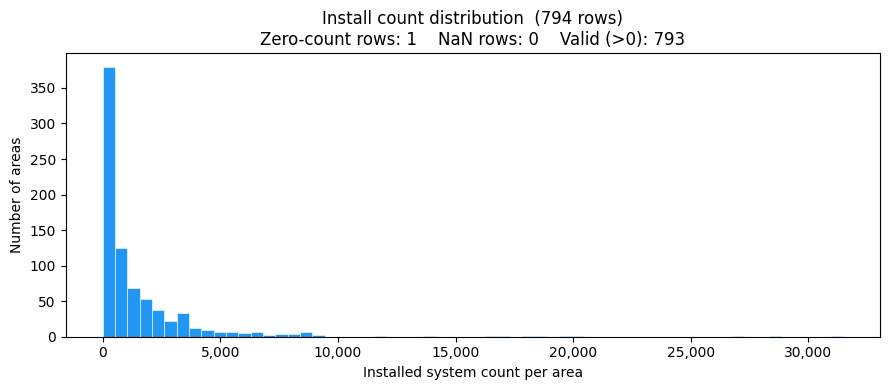

Zero-count rows : 1
NaN rows        : 0
Valid rows (>0) : 793
Median count    : 559
Max count       : 31,467

IMPACT: Zero-count rows should be excluded before training demand forecasts.


In [ ]:
# CHECK 2 — Zero / NaN install counts
san["installed_system_count"] = pd.to_numeric(san["installed_system_count"], errors="coerce")

zero_ct = (san["installed_system_count"] == 0).sum()
nan_ct  = san["installed_system_count"].isna().sum()
valid   = san[san["installed_system_count"] > 0]["installed_system_count"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(valid, bins=60, color="#2196F3", edgecolor="white", linewidth=0.4)
ax.set_xlabel("Installed system count per area")
ax.set_ylabel("Number of areas")
ax.set_title(
    f"Install count distribution  ({len(san):,} rows)\n"
    f"Zero-count rows: {zero_ct}    NaN rows: {nan_ct}    Valid (>0): {len(valid):,}"
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

print(f"Zero-count rows : {zero_ct}")
print(f"NaN rows        : {nan_ct}")
print(f"Valid rows (>0) : {len(valid):,}")
print(f"Median count    : {valid.median():,.0f}")
print(f"Max count       : {valid.max():,.0f}")
print()
if zero_ct > 0:
    print("IMPACT: Zero-count rows should be excluded before training demand forecasts.")
else:
    print("OK: No zero-count rows found.")

In [ ]:
# CHECK 3 — Duplicate area rows
postcode_rows = san[san["area_type"] == "postcode"]
lga_rows      = san[san["area_type"] == "lga"]

dup_pc  = postcode_rows[postcode_rows.duplicated(subset=["postcode"], keep=False)]
dup_lga = lga_rows[lga_rows.duplicated(subset=["lga"],      keep=False)]

print("── Duplicate postcodes ─────────────────────────────────")
print(f"  Postcode rows total     : {len(postcode_rows):,}")
print(f"  Rows with duplicate key : {len(dup_pc):,}")
if len(dup_pc) > 0:
    print()
    print(dup_pc[["postcode", "source_ids", "installed_system_count"]].head(10).to_string(index=False))
else:
    print("  OK — no duplicate postcode rows")

print()
print("── Duplicate LGAs ──────────────────────────────────────")
print(f"  LGA rows total          : {len(lga_rows):,}")
print(f"  Rows with duplicate key : {len(dup_lga):,}")
if len(dup_lga) > 0:
    print()
    print(dup_lga[["lga", "source_ids", "installed_system_count"]].head(10).to_string(index=False))
else:
    print("  OK — no duplicate LGA rows")

print()
print("IMPACT: Duplicates would double-count installs for affected areas.")
print("        De-duplicate before aggregating demand forecasts.")

── Duplicate postcodes ─────────────────────────────────
  Postcode rows total     : 713
  Rows with duplicate key : 0
  OK — no duplicate postcode rows

── Duplicate LGAs ──────────────────────────────────────
  LGA rows total          : 81
  Rows with duplicate key : 0
  OK — no duplicate LGA rows

IMPACT: Duplicates would double-count installs for affected areas.
        De-duplicate before aggregating demand forecasts.


## 2. Facility Nodes (`facility_nodes.csv`)

In [ ]:
# CHECK 4 — Missing facility capacity and accepted materials
def pct_missing(series):
    m = series.isna() | (series.astype(str).str.strip() == "")
    return m.sum(), m.mean() * 100

total = len(fac)
cap_miss, cap_pct = pct_missing(fac["capacity_kg_per_day"])
mat_miss, mat_pct = pct_missing(fac["accepted_materials"])
lat_miss, lat_pct = pct_missing(fac["lat"])
lon_miss, lon_pct = pct_missing(fac["lon"])

print("── Facility field completeness ─────────────────────────")
print(f"  Total facilities            : {total:,}")
print(f"  Missing capacity_kg_per_day : {cap_miss:,}  ({cap_pct:.1f}%)")
print(f"  Missing accepted_materials  : {mat_miss:,}  ({mat_pct:.1f}%)")
print(f"  Missing lat                 : {lat_miss:,}  ({lat_pct:.1f}%)")
print(f"  Missing lon                 : {lon_miss:,}  ({lon_pct:.1f}%)")
print()
print("── Capacity confidence breakdown ───────────────────────")
print(fac["capacity_confidence"].value_counts().to_string())
print()
print("── Facility type breakdown ─────────────────────────────")
print(fac["facility_type"].value_counts().to_string())
print()
print("IMPACT: capacity_kg_per_day is unknown for all/most facilities.")
print("        Capacity-constrained allocation must use assumed values.")
print("        accepted_materials is unknown — cannot confirm solar suitability.")

── Facility field completeness ─────────────────────────
  Total facilities            : 664
  Missing capacity_kg_per_day : 664  (100.0%)
  Missing accepted_materials  : 664  (100.0%)
  Missing lat                 : 0  (0.0%)
  Missing lon                 : 0  (0.0%)

── Capacity confidence breakdown ───────────────────────
capacity_confidence
unknown    664

── Facility type breakdown ─────────────────────────────
facility_type
Reprocessor                 282
Resource Recovery Centre    269
Landfill                     56
Hazardous waste              47
MRF                          10

IMPACT: capacity_kg_per_day is unknown for all/most facilities.
        Capacity-constrained allocation must use assumed values.
        accepted_materials is unknown — cannot confirm solar suitability.


## 3. Product Mix (`product_mix.csv`)

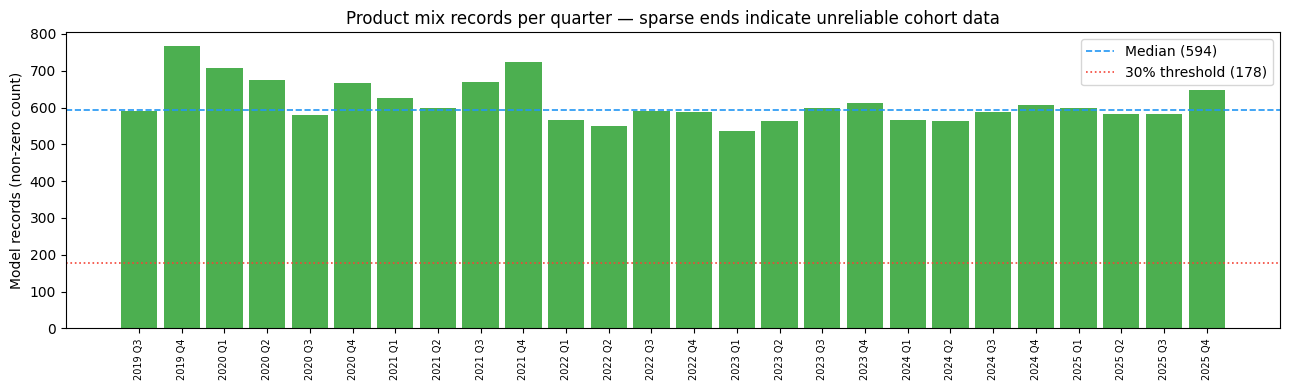

Total quarters         : 26
Median records/quarter : 594
Sparse threshold (30%) : 178
Sparse quarters        : 0

IMPACT: Cohort endpoints with sparse records undercount installs for that period.
        Weight or exclude sparse quarters when fitting lifecycle survival curves.


In [ ]:
# CHECK 5 — Sparse product-mix quarters
pm["count"] = pd.to_numeric(pm["count"], errors="coerce")
pm_valid    = pm[pm["count"] > 0].copy()

records_per_q = (
    pm_valid.groupby("install_quarter")
    .size()
    .reset_index(name="record_count")
    .sort_values("install_quarter")
)

median_r  = records_per_q["record_count"].median()
threshold = median_r * 0.3

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(range(len(records_per_q)), records_per_q["record_count"], color="#4CAF50", width=0.85)
ax.set_xticks(range(len(records_per_q)))
ax.set_xticklabels(records_per_q["install_quarter"], rotation=90, fontsize=7)
ax.set_ylabel("Model records (non-zero count)")
ax.set_title("Product mix records per quarter — sparse ends indicate unreliable cohort data")
ax.axhline(median_r,  color="#2196F3", linestyle="--", linewidth=1.2, label=f"Median ({median_r:.0f})")
ax.axhline(threshold, color="#f44336", linestyle=":",  linewidth=1.2, label=f"30% threshold ({threshold:.0f})")
ax.legend()
plt.tight_layout()
plt.show()

sparse = records_per_q[records_per_q["record_count"] < threshold]
print(f"Total quarters         : {len(records_per_q)}")
print(f"Median records/quarter : {median_r:.0f}")
print(f"Sparse threshold (30%) : {threshold:.0f}")
print(f"Sparse quarters        : {len(sparse)}")
if len(sparse) > 0:
    print()
    print(sparse.to_string(index=False))
print()
print("IMPACT: Cohort endpoints with sparse records undercount installs for that period.")
print("        Weight or exclude sparse quarters when fitting lifecycle survival curves.")

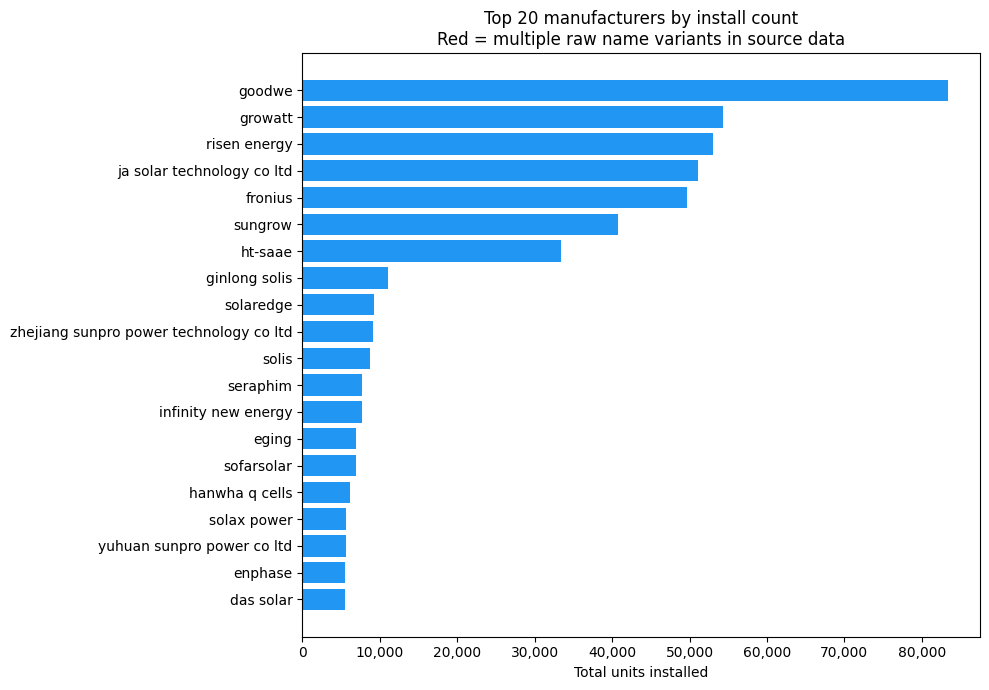

Unique normalised brand names  : 191
Brands with 2+ name variants   : 1

  'sunpower' has 2 variants:
    -> 'SUNPOWER'
    -> 'SunPower'

IMPACT: Inconsistent names split one manufacturer across separate rows.
        Normalise manufacturer column before aggregating material stream forecasts.


In [ ]:
# CHECK 6 — Brand name inconsistencies
pm["mfr_norm"] = (
    pm["manufacturer"]
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
)

brand_stats = (
    pm.groupby("mfr_norm")
    .agg(
        raw_variants = ("manufacturer", lambda x: sorted(x.unique().tolist())),
        total_count  = ("count", lambda x: pd.to_numeric(x, errors="coerce").sum()),
    )
    .reset_index()
)
brand_stats["variant_count"] = brand_stats["raw_variants"].apply(len)

multi = brand_stats[brand_stats["variant_count"] > 1].sort_values("total_count", ascending=False)
top20 = brand_stats.nlargest(20, "total_count").sort_values("total_count")
colors = ["#f44336" if v > 1 else "#2196F3" for v in top20["variant_count"]]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20["mfr_norm"], top20["total_count"], color=colors)
ax.set_xlabel("Total units installed")
ax.set_title("Top 20 manufacturers by install count\nRed = multiple raw name variants in source data")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

print(f"Unique normalised brand names  : {len(brand_stats):,}")
print(f"Brands with 2+ name variants   : {len(multi)}")
print()
if len(multi) > 0:
    for _, row in multi.iterrows():
        print(f"  '{row['mfr_norm']}' has {row['variant_count']} variants:")
        for v in row["raw_variants"]:
            print(f"    -> '{v}'")
        print()
print("IMPACT: Inconsistent names split one manufacturer across separate rows.")
print("        Normalise manufacturer column before aggregating material stream forecasts.")

---
## Model Readiness Verdict

| Model | Status | Blocker / Note |
|---|---|---|
| EOL demand forecast | **Ready** | Install cohorts available; centroids not required for cohort-only model |
| Inverter replacement forecast | **Ready** | Inverter product mix by quarter available; shorter lifespans make this the most immediate signal |
| Product mix / material forecast | **Ready** | Brand normalisation needed first — 30-min data-cleaning step |
| Collection priority scoring | **Partial** | Can score by install count and age; distance-to-facility scoring blocked until centroids are added |
| Facility allocation / routing | **Blocked** | Requires centroid lat/lon on area nodes + real or assumed facility capacity |

**Recommended build order:**

1. Normalise manufacturer names in `product_mix.csv`
2. Run EOL cohort model on `solar_area_nodes.csv` (postcode + install counts only)
3. Build inverter replacement wave from `product_mix.csv` inverter rows
4. Add postcode/LGA centroid spatial join to `solar_area_nodes.csv`
5. Add assumed facility capacity to `facility_nodes.csv`